# NB06 — Generative Augmentation Experiment

ทดสอบว่า LoRA-Boost ช่วย macro F1 ของ rare species จริงไหม
เทียบ 4 conditions (baseline / traditional / flux zero-shot / lora-boost) บน dataset เดียวกัน
ปรับการทดลองที่ config block แล้วรันใหม่ เก็บผลรายรอบใน results/experiments/

## 1. Setup

โหลด metadata, synthetic manifest, lora eval แล้วดึงรายการ rare species

In [1]:
from pathlib import Path
import pandas as pd, numpy as np

ROOT = Path('/workspace/lora-boost')
META = ROOT/'data'/'metadata'
SYNTH_ROOT = ROOT/'data'/'synthetic'          # <source>/<sid>/<file>.png
EXP_ROOT = ROOT/'results'/'experiments'

splits    = pd.read_csv(META/'splits.csv', dtype={'species_id': str})
species   = pd.read_csv(META/'species.csv', dtype={'species_id': str})
manifest  = pd.read_csv(META/'synthetic_manifest.csv', dtype={'species_id': str})
lora_eval = pd.read_csv(ROOT/'results'/'nb02'/'lora_eval.csv', dtype={'species_id': str})

In [2]:
rare_ids = species.loc[species.is_rare, 'species_id'].tolist()
max_rare = int(species.loc[species.is_rare, 'n_train'].max())

for name, df in [('splits', splits), ('species', species),
                 ('manifest', manifest), ('lora_eval', lora_eval)]:
    print(f'{name:10} {df.shape}  {list(df.columns)}')
print(f'\nrare: {len(rare_ids)} | max_rare: {max_rare}')

assert len(rare_ids) == 15 and max_rare == 71

splits     (239932, 6)  ['image_id', 'species_id', 'split', 'is_rare', 'organ', 'path']
species    (399, 12)  ['species_id', 'scientific_name', 'genus', 'is_rare', 'tropical_frac', 'n_total', 'n_train', 'n_val', 'n_test', 'n_flower', 'n_leaf', 'license']
manifest   (4712, 3)  ['path', 'species_id', 'source']
lora_eval  (15, 7)  ['species_id', 'consistency', 'memorization', 'diversity', 'organ_acc', 'name', 'flag']

rare: 15 | max_rare: 71


In [3]:
display(species.head(5))
display(splits.head(5))
display(manifest.head(5))
display(lora_eval.head(5))

,species_id,scientific_name,genus,is_rare,tropical_frac,n_total,n_train,n_val,n_test,n_flower,n_leaf,license
0,1416509,Nepenthes vieillardii Hook. f.,Nepenthes,True,0.989624,30,20,5,5,12,18,cc-by-sa
1,1419807,Vanilla planifolia Jacks. ex Andrews,Vanilla,True,0.722397,33,23,5,5,8,25,cc-by-sa
2,1376703,Petiveria alliacea L.,Petiveria,True,0.824782,38,28,5,5,9,29,cc-by-sa
3,1409195,Pereskia aculeata Mill.,Pereskia,True,0.790680,47,33,7,7,12,35,cc-by-sa
4,1408557,Pongamia pinnata (L.) Pierre,Pongamia,True,0.932655,52,36,8,8,17,35,cc-by-sa


,image_id,species_id,split,is_rare,organ,path
0,66d6455735fbdc582629dfc58940d9f409c7a9b3,1363021,train,False,flower,val/1363021/66d6455735fbdc582629dfc58940d9f409...
1,e86c71b84e97af16307801a1b986269fb4243fc1,1362954,val,False,leaf,val/1362954/e86c71b84e97af16307801a1b986269fb4...
2,8f954427dfbf8853bf8d655fa9bdda2801ebc025,1359498,train,False,flower,test/1359498/8f954427dfbf8853bf8d655fa9bdda280...
3,8d5066818d2fc73b454188e0a382493736f8c3a5,1369887,train,False,flower,train/1369887/8d5066818d2fc73b454188e0a3824937...
4,ad3474b4038f9aa31ec1c559fdeef3440a050bc1,1355978,train,False,flower,train/1355978/ad3474b4038f9aa31ec1c559fdeef344...


,path,species_id,source
0,1416509/1416509_flower_00000.png,1416509,lora_boost
1,1416509/1416509_flower_00001.png,1416509,lora_boost
2,1416509/1416509_flower_00002.png,1416509,lora_boost
3,1416509/1416509_flower_00003.png,1416509,lora_boost
4,1416509/1416509_flower_00004.png,1416509,lora_boost


,species_id,consistency,memorization,diversity,organ_acc,name,flag
0,1406486,0.492,0.0,0.629,1.000,Kigelia africana,low_consistency
1,1416509,0.525,0.0,0.591,0.833,Nepenthes vieillardii,ok
2,1376703,0.527,0.0,0.573,1.000,Petiveria alliacea,ok
3,1409195,0.546,0.0,0.612,1.000,Pereskia aculeata,ok
4,1419807,0.562,0.0,0.499,0.900,Vanilla planifolia,ok


## 2. Config

กำหนดพารามิเตอร์การทดลองทั้งหมดที่นี่ เรียงพารามิเตอร์ที่ปรับบ่อยไว้ด้านบน

In [39]:
config = {
    # ปรับบ่อย
    'head_cut':  {'rule': 'median'},          # C จุดตัด
    'budget':    {'shape': 'gap_pow', 'k': 0.5, 'p': 0.5, 'ratio_ref': 0.5},   # k เปลี่ยนต่อ exp
    'ref_point': {'combine': 'mid'},          # R = mid(C, max_rare)
    'loss':      {'type': 'focal', 'gamma': 2.0, 'alpha': None},
    'cap_to_R':  True,

    # ปรับนานๆ ที
    'conditions': ['A', 'B', 'C', 'D'],
    'seeds': [42, 0, 1],
    'organ_balance': True,
    'notes': 'es=overall_f1, k=0.5, R=mid, focal g2',
    'exp_id': None,

    # คงที่
    'early_stop': {'monitor': 'overall_f1', 'mode': 'max', 'patience': 10,   # monitor macro รวม ไม่เชียร์ rare
                   'min_delta': 0.002, 'max_epochs': 25,
                   'restore_best': True, 'enabled': True},
    'batch_size': 128,
    'lr_backbone': 1e-4, 'lr_fc': 1e-3, 'weight_decay': 1e-4,
    'keep_ckpt': False,
}

## 3. Resolve recipe

คำนวณ C, R และ budget ราย rare species จาก config 

In [40]:
def resolve_cut(rule, counts):
    # C = จุดตัด: เก็บ species ที่ n_train <= C
    if rule['rule'] == 'median':   return float(np.median(counts))
    if rule['rule'] == 'quantile': return float(np.quantile(counts, rule['q']))
    if rule['rule'] == 'abs':      return float(rule['value'])
    raise ValueError(rule)

def resolve_R(combine, C, max_rare):
    # R = จุดอ้างอิง อยู่ระหว่าง max_rare กับ C
    c = combine['combine']
    if c == 'mid':      return (C + max_rare) / 2
    if c == 'mid_geom': return float(np.sqrt(C * max_rare))
    if c == 'weighted': return combine['w'] * C + (1 - combine['w']) * max_rare
    if c == 'abs':      return float(combine['value'])
    raise ValueError(combine)

def budget_shape(gap, cfg):
    # gap = R - n  (>0 เท่านั้น) คืนจำนวน synthetic ดิบก่อนปัด
    g = np.clip(gap, 0, None)
    s = cfg['shape']
    if s == 'gap_pow':     return cfg['k'] * g ** cfg['p']
    if s == 'gap_log':     return cfg['k'] * np.log1p(g)
    if s == 'const_ratio': return None       # จัดการแยก (อิง n ไม่ใช่ gap)
    raise ValueError(s)

In [41]:
all_counts = species['n_train'].values
C = resolve_cut(config['head_cut'], all_counts)
R = resolve_R(config['ref_point'], C, max_rare)
print(f'C = {C:.1f}  |  R = {R:.1f}  |  max_rare = {max_rare}')

rare = species[species.is_rare].copy()
rare['gap'] = R - rare['n_train']
rare['b'] = budget_shape(rare['gap'].values, config['budget']).round().astype(int)
rare['b'] = rare['b'].clip(lower=0)
rare['n_final'] = rare['n_train'] + rare['b']
rare['ratio'] = (rare['b'] / rare['n_train']).round(3)
print(rare[['scientific_name', 'n_train', 'b', 'n_final', 'ratio']]
      .sort_values('n_train').to_string(index=False))

C = 121.0  |  R = 96.0  |  max_rare = 71
                     scientific_name  n_train  b  n_final  ratio
      Nepenthes vieillardii Hook. f.       20  4       24  0.200
Vanilla planifolia Jacks. ex Andrews       23  4       27  0.174
               Petiveria alliacea L.       28  4       32  0.143
             Pereskia aculeata Mill.       33  4       37  0.121
        Pongamia pinnata (L.) Pierre       36  4       40  0.111
      Kigelia africana (Lam.) Benth.       37  4       41  0.108
      Alocasia odora (Lindl.) K.Koch       38  4       42  0.105
           Pereskia grandifolia Haw.       40  4       44  0.100
     Barringtonia asiatica (L.) Kurz       47  4       51  0.085
Tradescantia zebrina Heynh. ex Bosse       49  3       52  0.061
                Cobaea scandens Cav.       49  3       52  0.061
  Dendrobium victoriae-reginae Loher       51  3       54  0.059
Lagenaria siceraria (Molina) Standl.       56  3       59  0.054
                  Acalypha indica L.       66  3 

## 4. Run folder

สร้าง exp_id จาก config เปิด run folder และ freeze config ลงไป
แต่ละ config ได้ folder แยก ไม่ทับกัน

In [42]:
import yaml

def make_exp_id(cfg):
    b = cfg['budget']
    slug = (f"C{cfg['head_cut']['rule']}_{b['shape']}_k{b['k']}_p{b['p']}"
            f"_{cfg['ref_point']['combine']}_{cfg['loss']['type']}")
    existing = [int(p.name.split('_')[1]) for p in EXP_ROOT.glob('exp_*')]
    n = max(existing) + 1 if existing else 0
    dup = [p.name for p in EXP_ROOT.glob('exp_*') if p.name.split('_', 2)[2] == slug]
    if dup:
        print(f'[warn] config นี้เคยรันแล้ว: {dup[0]} — รันต่อจะได้ folder ใหม่ slug เดิม')
    return f'exp_{n:04d}_{slug}'

exp_id = config['exp_id'] or make_exp_id(config)
run_dir = EXP_ROOT/exp_id
(run_dir/'seeds').mkdir(parents=True, exist_ok=True)

with open(run_dir/'config.yaml', 'w') as f:
    yaml.safe_dump({**config, '_resolved': {'C': C, 'R': R, 'max_rare': max_rare}},
                   f, sort_keys=False, allow_unicode=True)

print('run_dir:', run_dir.name)

[warn] config นี้เคยรันแล้ว: exp_0003_Cmedian_gap_pow_k0.5_p0.5_mid_focal — รันต่อจะได้ folder ใหม่ slug เดิม
run_dir: exp_0006_Cmedian_gap_pow_k0.5_p0.5_mid_focal


## 5. Preview

ตรวจ budget ราย species พร้อม consistency ของ LoRA แล้วเซฟลง run folder
ratio ควรอยู่ในเกณฑ์ (อ้างอิง 0.5)

In [43]:
prev = (rare[['species_id', 'n_train', 'gap', 'b', 'n_final', 'ratio']]
        .merge(lora_eval[['species_id', 'name', 'consistency', 'organ_acc', 'flag']],
               on='species_id', how='left')
        .sort_values('n_train').reset_index(drop=True))
prev = prev[['name', 'n_train', 'b', 'n_final', 'ratio', 'consistency', 'organ_acc', 'flag']]

ref = config['budget']['ratio_ref']
print(f"synthetic รวม {prev.b.sum()} รูป | ratio {prev.ratio.min():.2f}-{prev.ratio.max():.2f} "
      f"| เกิน ref ({ref}): {(prev.ratio > ref).sum()} ตัว")

prev.to_csv(run_dir/'budget_preview.csv', index=False)
prev

synthetic รวม 53 รูป | ratio 0.03-0.20 | เกิน ref (0.5): 0 ตัว


,name,n_train,b,n_final,ratio,consistency,organ_acc,flag
0,Nepenthes vieillardii,20,4,24,0.200,0.525,0.833,ok
1,Vanilla planifolia,23,4,27,0.174,0.562,0.900,ok
2,Petiveria alliacea,28,4,32,0.143,0.527,1.000,ok
3,Pereskia aculeata,33,4,37,0.121,0.546,1.000,ok
4,Pongamia pinnata,36,4,40,0.111,0.671,1.000,ok
5,Kigelia africana,37,4,41,0.108,0.492,1.000,low_consistency
6,Alocasia odora,38,4,42,0.105,0.718,0.900,ok
7,Pereskia grandifolia,40,4,44,0.100,0.596,0.933,ok
8,Barringtonia asiatica,47,4,51,0.085,0.772,1.000,ok
9,Tradescantia zebrina,49,3,52,0.061,0.747,0.767,ok


## 6. Subset + cap

เก็บเฉพาะ class ที่ n_train <= C ตัดหัวออก, cap เพดาน non-rare ที่เกิน R ลงมา (train เท่านั้น)
แล้วสร้าง label map ใหม่ของ class ที่เหลือ

In [44]:
keep = species[species.n_train <= C].copy()                 # ตัดหัว n_train > C
keep_ids = set(keep.species_id)
label_map = {sid: i for i, sid in enumerate(sorted(keep_ids))}

sub = splits[splits.species_id.isin(keep_ids)].copy()        # ทั้ง train/val/test ของ class ที่เก็บ
print(f'classes: {len(keep_ids)} (จาก {species.species_id.nunique()})  | rows: {len(sub)}')
print(sub.split.value_counts().to_dict())

classes: 200 (จาก 399)  | rows: 15394
{'train': 10784, 'test': 2305, 'val': 2305}


In [45]:
rng = np.random.default_rng(0)   # cap ใช้ seed คงที่ ทุก condition/seed เห็น train pool เดียวกัน

def cap_train(df, cap, rare_set, rng):
    out = []
    for sid, g in df.groupby('species_id'):
        tr = g[g.split == 'train']
        if sid not in rare_set and len(tr) > cap:           # non-rare เกิน R → สุ่มเก็บ cap รูป
            tr = tr.iloc[rng.permutation(len(tr))[:cap]]
        out.append(pd.concat([tr, g[g.split != 'train']]))  # val/test คงเดิม
    return pd.concat(out).reset_index(drop=True)

rare_set = set(rare_ids)
sub = cap_train(sub, int(R), rare_set, rng)
print('after cap | train rows:', (sub.split == 'train').sum())

after cap | train rows: 10547


In [46]:
subset_info = keep[['species_id', 'scientific_name', 'is_rare', 'n_train']].copy()
subset_info['label'] = subset_info.species_id.map(label_map)
tr_count = sub[sub.split == 'train'].groupby('species_id').size()
subset_info['n_train_after'] = subset_info.species_id.map(tr_count).fillna(0).astype(int)
subset_info = subset_info.sort_values('n_train_after')

subset_info.to_csv(run_dir/'species_subset.csv', index=False)
print(subset_info.n_train_after.describe()[['min', '50%', 'max']].to_dict())

{'min': 12.0, '50%': 50.5, 'max': 96.0}


## 7. Build train set ราย condition

ฟังก์ชันประกอบ train set: real (หลัง subset+cap) + เติม synthetic ตาม condition
A ไม่เติม, B duplicate real, C flux zero-shot, D lora-boost
จำนวนเติม = budget b แบ่ง flower/leaf ตามสัดส่วน real

In [47]:
IMG_ROOT = ROOT/'data'/'raw'/'plantnet_300K'/'images'   # real (relative ต่อ root นี้)

def organ_split(b, n_flower, n_leaf):
    # แบ่ง b เป็น (flower, leaf) ตามสัดส่วน real
    f = round(b * n_flower / (n_flower + n_leaf))
    return f, b - f

def sample_aug(cond, sid, organ, k, real_tr, rng):
    # คืน rows ที่จะเติม (path relative, source, species_id, organ)
    if cond == 'B':
        pool = real_tr[(real_tr.species_id == sid) & (real_tr.organ == organ)]
        sel = pool.iloc[rng.integers(0, len(pool), k)]      # dup ซ้ำได้ (transform ต่างกัน)
        return pd.DataFrame({'path': sel.path.values, 'source': 'real_dup',
                             'species_id': sid, 'organ': organ})
    src = 'flux_zeroshot' if cond == 'C' else 'lora_boost'
    pool = manifest[(manifest.source == src) & (manifest.species_id == sid)]
    pool = pool[pool.path.str.split('_').str[-2] == organ]
    sel = pool.iloc[rng.permutation(len(pool))[:k]]         # subsample ไม่ซ้ำ
    return pd.DataFrame({'path': sel.path.values, 'source': src,
                         'species_id': sid, 'organ': organ})

In [48]:
b_map = dict(zip(rare.species_id, rare.b))
nfl = species.set_index('species_id')[['n_flower', 'n_leaf']]

def build_train(cond, seed):
    rng = np.random.default_rng(seed)
    real_tr = sub[sub.split == 'train'][['path', 'species_id', 'organ']].copy()
    real_tr['source'] = 'real'
    parts = [real_tr]

    if cond != 'A':
        for sid in rare_ids:
            b = int(b_map[sid])
            nf, nl = organ_split(b, nfl.loc[sid, 'n_flower'], nfl.loc[sid, 'n_leaf'])
            for organ, k in [('flower', nf), ('leaf', nl)]:
                if k > 0:
                    parts.append(sample_aug(cond, sid, organ, k, real_tr, rng))

    df = pd.concat(parts, ignore_index=True)
    df['label'] = df.species_id.map(label_map)
    return df

In [49]:
for cond in ['A', 'B', 'C', 'D']:
    d = build_train(cond, 42)
    syn = d[d.source != 'real']
    print(f'{cond}: {len(d):,} rows | +{len(syn)} aug | sources {d.source.value_counts().to_dict()}')

# ยืนยันว่า path resolve ได้จริง
d = build_train('D', 42)
r = d[d.source == 'real'].iloc[0]
s = d[d.source == 'lora_boost'].iloc[0]
assert (IMG_ROOT/r.path).exists(), f'real missing: {r.path}'
assert (SYNTH_ROOT/s.source/s.path).exists(), f'synth missing: {s.path}'
print('paths OK')

A: 10,547 rows | +0 aug | sources {'real': 10547}
B: 10,600 rows | +53 aug | sources {'real': 10547, 'real_dup': 53}
C: 10,600 rows | +53 aug | sources {'real': 10547, 'flux_zeroshot': 53}
D: 10,600 rows | +53 aug | sources {'real': 10547, 'lora_boost': 53}
paths OK


## 8. Data + model + train

เตรียม Dataset/transforms, โมเดล, loss, eval และ train loop ที่วัด val ทุก epoch
ใช้ early stop หยุดเองและเก็บ weight ของ epoch ที่ดีสุด

In [50]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import sys
sys.unraisablehook = lambda *a, **k: None

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim, random
import torchvision.transforms as TF
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score
from PIL import Image
from tqdm.auto import tqdm

DEVICE = 'cuda'
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

base_tf = TF.Compose([TF.Resize((IMG_SIZE, IMG_SIZE)), TF.ToTensor(), TF.Normalize(MEAN, STD)])
traditional_tf = TF.Compose([
    TF.Resize((IMG_SIZE, IMG_SIZE)), TF.RandomHorizontalFlip(), TF.RandomRotation(30),
    TF.ColorJitter(0.2, 0.2, 0.2), TF.ToTensor(), TF.Normalize(MEAN, STD)])

class PlantDataset(Dataset):
    def __init__(self, df, train=True):
        self.paths, self.sources, self.labels = df.path.tolist(), df.source.tolist(), df.label.tolist()
        self.train = train
    def __len__(self): return len(self.paths)
    def _resolve(self, path, src):
        root = SYNTH_ROOT/src if src in ('flux_zeroshot', 'lora_boost') else IMG_ROOT
        return root/path
    def __getitem__(self, i):
        img = Image.open(self._resolve(self.paths[i], self.sources[i])).convert('RGB')
        tf = traditional_tf if (self.train and self.sources[i] == 'real_dup') else base_tf
        return tf(img), self.labels[i]

class CachedDataset(Dataset):
    def __init__(self, df, train=True):
        self.sources = df.source.tolist()
        self.labels = df.label.tolist()
        self.train = train
        # preload: decode รูปทุกใบเป็น uint8 tensor เก็บ RAM ครั้งเดียว
        self.imgs = []
        for path, src in tqdm(zip(df.path, df.source), total=len(df), desc='cache'):
            root = SYNTH_ROOT/src if src in ('flux_zeroshot', 'lora_boost') else IMG_ROOT
            img = Image.open(root/path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            self.imgs.append(torch.from_numpy(np.array(img)))   # HWC uint8

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img = Image.fromarray(self.imgs[i].numpy())             # คืนเป็น PIL ให้ transform เดิมใช้ได้
        tf = traditional_tf if (self.train and self.sources[i] == 'real_dup') else base_tf
        return tf(img), self.labels[i]

In [51]:
def real_split(which):
    d = sub[sub.split == which][['path', 'species_id']].copy()
    d['source'] = 'real'; d['label'] = d.species_id.map(label_map)
    return d

val_df, test_df = real_split('val'), real_split('test')
all_labels = list(range(len(label_map)))
rare_labels = [label_map[s] for s in rare_ids]

def build_model(seed):
    set_seed(seed)                                          # init fc เหมือนกันทุก cond ใน seed เดียว
    m = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, len(label_map))
    return m.to(DEVICE)

def make_optimizer(model):
    fc_ids = {id(p) for p in model.fc.parameters()}
    backbone = [p for p in model.parameters() if id(p) not in fc_ids]
    return optim.AdamW([{'params': backbone, 'lr': config['lr_backbone']},
                        {'params': list(model.fc.parameters()), 'lr': config['lr_fc']}],
                       weight_decay=config['weight_decay'])

class FocalLoss(nn.Module):
    def __init__(self, gamma): super().__init__(); self.gamma = gamma
    def forward(self, logits, y):
        logp = F.log_softmax(logits, 1).gather(1, y[:, None]).squeeze(1)
        return (-((1 - logp.exp()) ** self.gamma) * logp).mean()

def make_criterion(cfg):
    if cfg['type'] == 'ce':    return nn.CrossEntropyLoss()
    if cfg['type'] == 'focal': return FocalLoss(cfg['gamma'])
    raise ValueError(cfg['type'])

In [52]:
val_ds = CachedDataset(val_df, train=False)
test_ds = CachedDataset(test_df, train=False)
print(f'cached val {len(val_ds)} | test {len(test_ds)}')

cache:   0%|          | 0/2305 [00:00<?, ?it/s]

cache:   0%|          | 0/2305 [00:00<?, ?it/s]

cached val 2305 | test 2305


In [53]:
from sklearn.metrics import f1_score, recall_score, precision_score

@torch.no_grad()
def eval_split(model, ds):
    model.eval()
    loader = DataLoader(ds, batch_size=config['batch_size'], num_workers=0)
    preds, gts = [], []
    for x, y in tqdm(loader, desc='eval', leave=False):
        with torch.autocast(DEVICE, dtype=torch.bfloat16):
            out = model(x.to(DEVICE))
        preds.append(out.argmax(1).cpu()); gts.append(y)
    pred = torch.cat(preds).numpy(); gt = torch.cat(gts).numpy()

    kw = dict(labels=all_labels, average=None, zero_division=0)
    f1   = f1_score(gt, pred, **kw)
    rec  = recall_score(gt, pred, **kw)        # recall ราย class = accuracy ราย species
    prec = precision_score(gt, pred, **kw)     # precision ไว้จับ false positive (distribution shift)
    per = lambda a: {sid: float(a[label_map[sid]]) for sid in rare_ids}

    return {
        'overall_acc':    float((pred == gt).mean()),       # top-1 รวม (sanity)
        'macro_f1':       float(f1.mean()),                 # ตัวที่ monitor
        'rare_f1':        float(f1[rare_labels].mean()),
        'rare_recall':    float(rec[rare_labels].mean()),   # primary ใหม่
        'rare_precision': float(prec[rare_labels].mean()),  # diagnostic ใหม่
        'rare_f1_per_species':        per(f1),
        'rare_recall_per_species':    per(rec),
        'rare_precision_per_species': per(prec),
    }

In [54]:
def train_one_epoch(model, loader, opt, crit):
    model.train(); tot = n = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt.zero_grad()
        with torch.autocast(DEVICE, dtype=torch.bfloat16):
            loss = crit(model(x), y)
        loss.backward(); opt.step()
        tot += loss.item() * len(y); n += len(y)
    return tot / n

def train_one(cond, seed, es):
    set_seed(seed)
    train_ds = CachedDataset(build_train(cond, seed), train=True)     # preload train ของ run นี้
    loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)
    model = build_model(seed)
    opt = make_optimizer(model)
    crit = make_criterion(config['loss'])

    mkey = 'macro_f1' if es.get('monitor') == 'overall_f1' else es['monitor']   # monitor overall macro
    best = {'rare_f1': -1, 'overall_f1': -1, 'monitor_val': -1, 'epoch': -1, 'state': None}
    hist, bad = [], 0
    for ep in range(es['max_epochs']):
        loss = train_one_epoch(model, loader, opt, crit)
        v = eval_split(model, val_ds)                                 # ใช้ val ที่ cache แล้ว
        hist.append({'epoch': ep, 'loss': loss, 'overall_acc': v['overall_acc'],
                     'macro_f1': v['macro_f1'], 'rare_f1': v['rare_f1'],
                     'rare_recall': v['rare_recall'], 'rare_precision': v['rare_precision']})
        cur = v[mkey]
        improved = cur > best['monitor_val'] + es['min_delta']
        if improved:
            best.update(rare_f1=v['rare_f1'], overall_f1=v['macro_f1'], monitor_val=cur,
                        epoch=ep, state={k: t.detach().cpu().clone()
                                         for k, t in model.state_dict().items()})
            bad = 0
        else:
            bad += 1
        print(f"  ep{ep:02d} | loss {loss:.3f} | acc {v['overall_acc']:.3f} | "
              f"macro {v['macro_f1']:.3f}{'*' if improved else ' '} | "
              f"rareF1 {v['rare_f1']:.3f} | rareRec {v['rare_recall']:.3f}"
              + ('' if improved else f"  ({bad}/{es['patience']})"))
        if es['enabled'] and es['patience'] and bad >= es['patience']:
            print(f"  stop @ ep{ep} (best ep{best['epoch']})"); break

    if es['restore_best'] and best['state']:
        model.load_state_dict(best['state'])
    return model, best, hist

## 9. Train

เทรน 4 condition × 3 seed แบ่ง 2 phase: 
- phase 1 หา early-stop policy
- phase 2 รันที่เหลือ
  
ผลแต่ละ run เก็บใน run folder, headline เทียบที่ index.csv

### Phase 1: หา early-stop policy

เทรน A / seed 42 ปิด early stop รันเต็ม max_epochs เพื่อตัดสินใจเลือกค่า patience

In [21]:
es_p1 = {**config['early_stop'], 'enabled': False}      # ปิด early stop ดูเต็มเส้น
import time
t0 = time.time()
model_a, best_a, hist_a = train_one('A', 42, es_p1)
print(f"\nbest macro {best_a['overall_f1']:.3f} @ ep{best_a['epoch']} "
      f"(rare {best_a['rare_f1']:.3f}) | {(time.time()-t0)/len(hist_a):.0f}s/epoch "
      f"| รวม {(time.time()-t0)/60:.1f} min")

cache:   0%|          | 0/10547 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

eval:   0%|          | 0/19 [00:00<?, ?it/s]

  ep00 | loss 3.101 | acc 0.600 | macro 0.455* | rareF1 0.412 | rareRec 0.407


  0%|          | 0/82 [00:00<?, ?it/s]

...

eval:   0%|          | 0/19 [00:00<?, ?it/s]

  ep38 | loss 0.000 | acc 0.721 | macro 0.624  | rareF1 0.633 | rareRec 0.626  (14/15)


  0%|          | 0/82 [00:00<?, ?it/s]

eval:   0%|          | 0/19 [00:00<?, ?it/s]

  ep39 | loss 0.000 | acc 0.724 | macro 0.623  | rareF1 0.626 | rareRec 0.628  (15/15)

best macro 0.635 @ ep24 (rare 0.627) | 31s/epoch | รวม 20.4 min


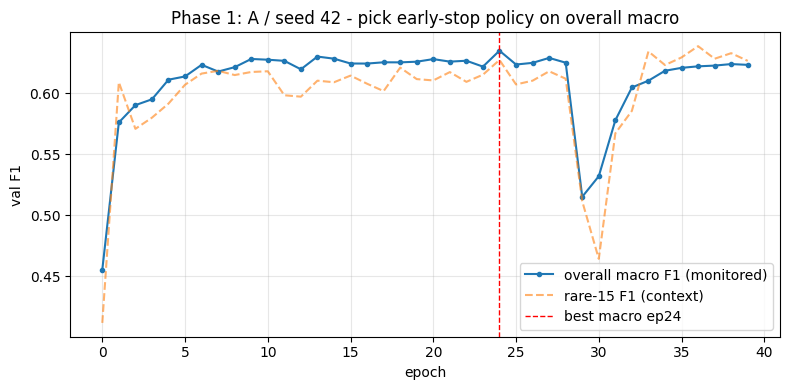

In [22]:
import matplotlib.pyplot as plt

h = pd.DataFrame(hist_a)
best_ep = int(h.macro_f1.idxmax())
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h.epoch, h.macro_f1, '-o', ms=3, label='overall macro F1 (monitored)')
ax.plot(h.epoch, h.rare_f1, '--', alpha=0.6, label='rare-15 F1 (context)')
ax.axvline(best_ep, color='r', ls='--', lw=1, label=f'best macro ep{best_ep}')
ax.set_xlabel('epoch'); ax.set_ylabel('val F1')
ax.set_title('Phase 1: A / seed 42 - pick early-stop policy on overall macro')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(run_dir/'phase1_curve.png', dpi=120)
plt.show()

### Phase 2 — รันทุก condition × seed

ใช้ policy จาก phase 1 (patience 15) วน A/B/C/D × seed 42/0/1 ครบ 12 run
แต่ละ run เทรน + eval test เซฟ metrics/manifest ลง run folder

In [55]:
import json

def save_run(cond, seed, model, best, hist):
    sd = run_dir/'seeds'/f's{seed}'
    sd.mkdir(parents=True, exist_ok=True)

    test_res = eval_split(model, test_ds)
    build_train(cond, seed).to_csv(sd/f'manifest_{cond}.csv', index=False)
    json.dump(hist, open(sd/f'history_{cond}.json', 'w'))            # per-epoch ไว้ plot

    metrics = {'cond': cond, 'seed': seed,
               'val_rare_f1': best['rare_f1'], 'val_overall_f1': best['overall_f1'],
               'test_rare_f1': test_res['rare_f1'], 'test_overall_f1': test_res['macro_f1'],
               'test_overall_acc': test_res['overall_acc'],                  # ใหม่
               'test_rare_recall': test_res['rare_recall'],                  # ใหม่ (primary)
               'test_rare_precision': test_res['rare_precision'],            # ใหม่ (diag)
               'rare_f1_per_species': test_res['rare_f1_per_species'],
               'rare_recall_per_species': test_res['rare_recall_per_species'],      # ใหม่
               'rare_precision_per_species': test_res['rare_precision_per_species'], # ใหม่
               'best_epoch': best['epoch'], 'stop_epoch': hist[-1]['epoch'],
               'n_classes': len(label_map)}
    json.dump(metrics, open(sd/f'metrics_{cond}.json', 'w'), indent=2)

    if config['keep_ckpt']:
        torch.save(model.state_dict(), sd/f'ckpt_{cond}.pt')
    return metrics

In [56]:
import time

for seed in config['seeds']:
    for cond in config['conditions']:
        mpath = run_dir/'seeds'/f's{seed}'/f'metrics_{cond}.json'
        if mpath.exists():
            print(f'skip {cond}/s{seed} (มีแล้ว)')
            continue
        t0 = time.time()
        print(f'\n=== {cond} / seed {seed} ===')
        model, best, hist = train_one(cond, seed, config['early_stop'])
        m = save_run(cond, seed, model, best, hist)
        print(f"  rare {m['test_rare_f1']:.3f} | rec {m['test_rare_recall']:.3f} "
              f"| acc {m['test_overall_acc']:.3f} | best_ep {m['best_epoch']} "
              f"stop_ep {m['stop_epoch']} | {(time.time()-t0)/60:.1f} min")
        del model; torch.cuda.empty_cache()


=== A / seed 42 ===


cache:   0%|          | 0/10547 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

eval:   0%|          | 0/19 [00:00<?, ?it/s]

  ep00 | loss 3.101 | acc 0.600 | macro 0.455* | rareF1 0.412 | rareRec 0.407


...

  0%|          | 0/82 [00:00<?, ?it/s]

eval:   0%|          | 0/19 [00:00<?, ?it/s]

  ep23 | loss 0.000 | acc 0.712 | macro 0.619  | rareF1 0.627 | rareRec 0.618  (10/10)
  stop @ ep23 (best ep13)


eval:   0%|          | 0/19 [00:00<?, ?it/s]

  rare 0.662 | rec 0.672 | acc 0.724 | best_ep 13 stop_ep 23 | 12.3 min


In [57]:
import json
rows = []
for seed in config['seeds']:
    for cond in config['conditions']:
        p = run_dir/'seeds'/f's{seed}'/f'metrics_{cond}.json'
        if p.exists():
            rows.append(json.load(open(p)))
res = pd.DataFrame(rows)
print(f'{len(res)}/12 run')
print(res[['cond', 'seed', 'test_rare_f1', 'test_rare_recall', 'test_rare_precision',
           'test_overall_f1', 'test_overall_acc', 'best_epoch', 'stop_epoch']]
      .round(3).to_string(index=False))

12/12 run
cond  seed  test_rare_f1  test_rare_recall  test_rare_precision  test_overall_f1  test_overall_acc  best_epoch  stop_epoch
   A    42         0.613             0.610                0.639            0.627             0.715           9          19
   B    42         0.617             0.669                0.589            0.630             0.711           4          14
   C    42         0.592             0.628                0.583            0.625             0.719          10          20
   D    42         0.634             0.646                0.640            0.628             0.718           7          17
   A     0         0.678             0.663                0.723            0.627             0.712           6          16
   B     0         0.638             0.694                0.619            0.623             0.714           4          14
   C     0         0.642             0.647                0.677            0.611             0.710           4          14
   D  

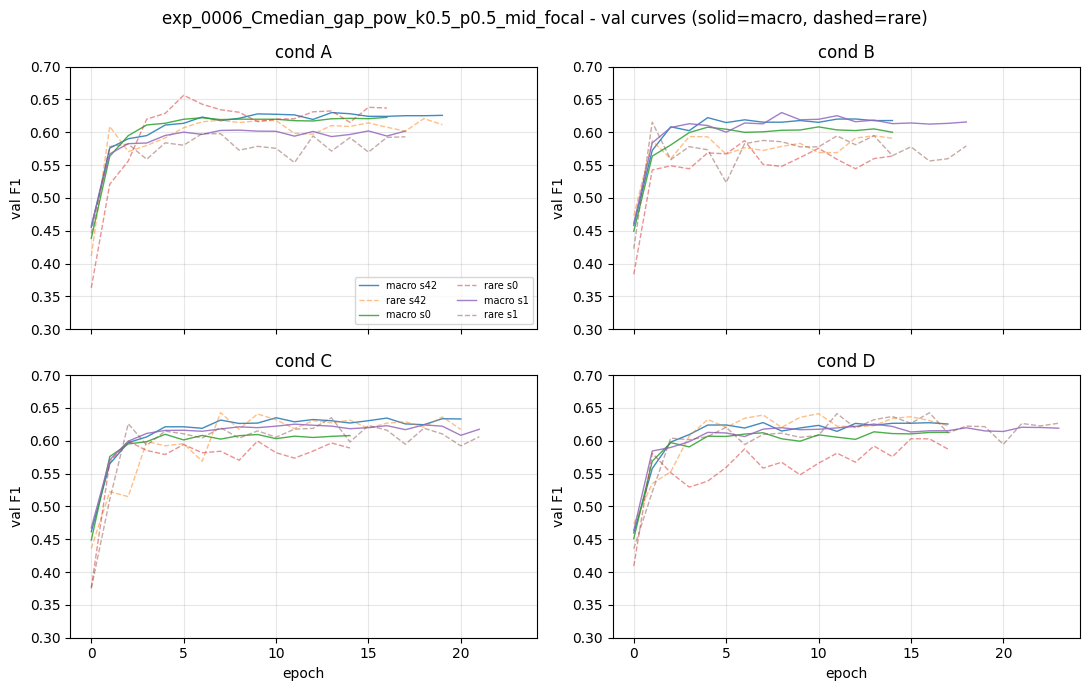

In [58]:
import json, matplotlib.pyplot as plt

(run_dir/'figs').mkdir(exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, cond in zip(axes.ravel(), config['conditions']):
    for seed in config['seeds']:
        hp = run_dir/'seeds'/f's{seed}'/f'history_{cond}.json'
        if not hp.exists():
            continue
        h = pd.DataFrame(json.load(open(hp)))
        ax.plot(h.epoch, h.macro_f1, '-', lw=1, alpha=0.85, label=f'macro s{seed}')
        ax.plot(h.epoch, h.rare_f1, '--', lw=1, alpha=0.5, label=f'rare s{seed}')
    ax.set_title(f'cond {cond}'); ax.set_ylim(0.3, 0.7)
    ax.grid(alpha=0.3); ax.set_ylabel('val F1')
axes[0, 0].legend(fontsize=7, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel('epoch')
fig.suptitle(f'{exp_id} - val curves (solid=macro, dashed=rare)')
plt.tight_layout()
plt.savefig(run_dir/'figs'/'curves.png', dpi=120)
plt.show()

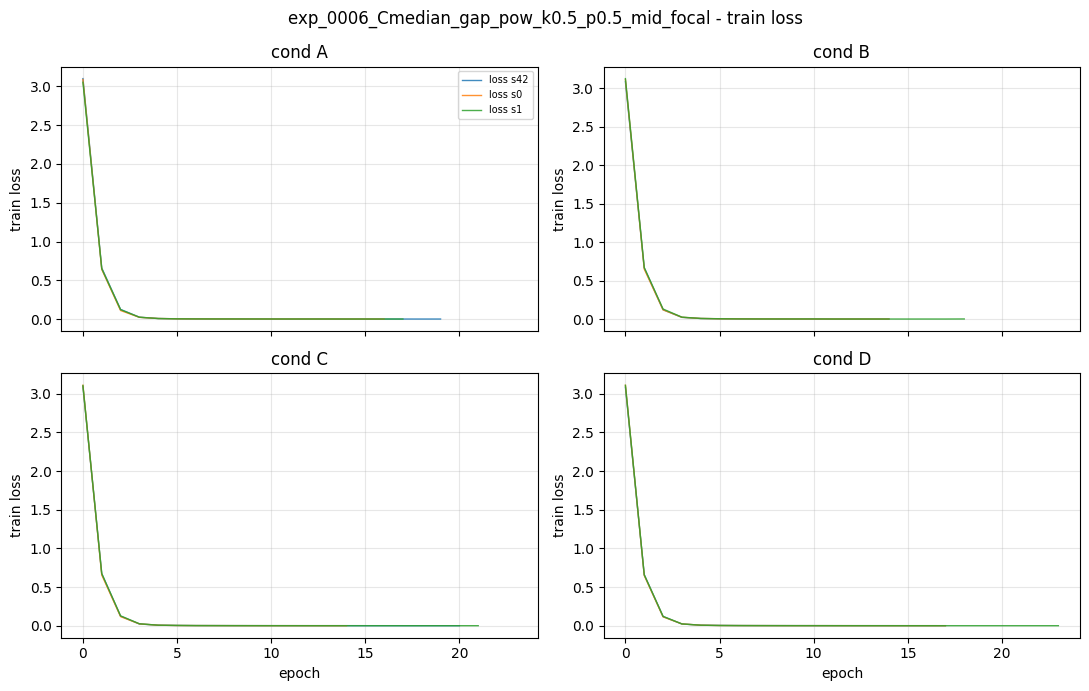

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, cond in zip(axes.ravel(), config['conditions']):
    for seed in config['seeds']:
        hp = run_dir/'seeds'/f's{seed}'/f'history_{cond}.json'
        if not hp.exists():
            continue
        h = pd.DataFrame(json.load(open(hp)))
        ax.plot(h.epoch, h.loss, '-', lw=1, alpha=0.85, label=f'loss s{seed}')
    ax.set_title(f'cond {cond}'); ax.grid(alpha=0.3); ax.set_ylabel('train loss')
axes[0, 0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel('epoch')
fig.suptitle(f'{exp_id} - train loss')
plt.tight_layout()
plt.savefig(run_dir/'figs'/'loss_curves.png', dpi=120)
plt.show()

## 10. Aggregate

รวม metrics 12 run, สรุป mean ± std ราย condition (rare F1, overall F1, rare recall, rare precision, acc) เทียบ D กับ A/B/C บันทึก index.csv

In [60]:
import json

rows = [json.load(open(run_dir/'seeds'/f's{s}'/f'metrics_{c}.json'))
        for s in config['seeds'] for c in config['conditions']]
res = pd.DataFrame(rows)

agg = res.groupby('cond').agg(
    rare_mean=('test_rare_f1', 'mean'),       rare_std=('test_rare_f1', 'std'),
    rec_mean=('test_rare_recall', 'mean'),    rec_std=('test_rare_recall', 'std'),
    prec_mean=('test_rare_precision', 'mean'),
    overall_mean=('test_overall_f1', 'mean'), overall_std=('test_overall_f1', 'std'),
    acc_mean=('test_overall_acc', 'mean'),
).round(4)
print(agg.to_string())

      rare_mean  rare_std  rec_mean  rec_std  prec_mean  overall_mean  overall_std  acc_mean
cond                                                                                        
A        0.6449    0.0324    0.6500   0.0355     0.6744        0.6281       0.0021    0.7137
B        0.6372    0.0203    0.6990   0.0325     0.6124        0.6247       0.0044    0.7119
C        0.6297    0.0335    0.6468   0.0185     0.6438        0.6207       0.0085    0.7140
D        0.6500    0.0148    0.6571   0.0135     0.6798        0.6290       0.0055    0.7186


In [61]:
print('rare-15 F1 (mean across 3 seeds):\n')
for metric, col in [('rare F1', 'rare_mean'), ('rare recall', 'rec_mean')]:
    d = agg.loc['D', col]
    print(f'{metric}:')
    for c in ['A', 'B', 'C']:
        diff = d - agg.loc[c, col]
        print(f"  D - {c}: {diff:+.4f}   (D {d:.4f} vs {c} {agg.loc[c, col]:.4f})")
    print()
print(f"D std: rare-F1 {agg.loc['D','rare_std']:.3f} | recall {agg.loc['D','rec_std']:.3f}")

rare-15 F1 (mean across 3 seeds):

rare F1:
  D - A: +0.0051   (D 0.6500 vs A 0.6449)
  D - B: +0.0128   (D 0.6500 vs B 0.6372)
  D - C: +0.0203   (D 0.6500 vs C 0.6297)

rare recall:
  D - A: +0.0071   (D 0.6571 vs A 0.6500)
  D - B: -0.0419   (D 0.6571 vs B 0.6990)
  D - C: +0.0103   (D 0.6571 vs C 0.6468)

D std: rare-F1 0.015 | recall 0.013


In [62]:
b = config['budget']
idx_row = {
    'exp_id': exp_id, 'es_monitor': config['early_stop']['monitor'],   # ใหม่: กันสับสน old/new
    'C': C, 'R': R, 'n_classes': len(label_map),
    'shape': b['shape'], 'k': b['k'], 'p': b['p'], 'combine': config['ref_point']['combine'],
    'loss': config['loss']['type'], 'gamma': config['loss'].get('gamma'),
    'cap': config['cap_to_R'], 'seeds': str(config['seeds']),
    'A_rare': agg.loc['A','rare_mean'], 'B_rare': agg.loc['B','rare_mean'],
    'C_rare': agg.loc['C','rare_mean'], 'D_rare': agg.loc['D','rare_mean'],
    'D_rare_std': agg.loc['D','rare_std'],
    'A_rec': agg.loc['A','rec_mean'], 'D_rec': agg.loc['D','rec_mean'],   # ใหม่
    'dDA': agg.loc['D','rare_mean']-agg.loc['A','rare_mean'],
    'dDB': agg.loc['D','rare_mean']-agg.loc['B','rare_mean'],
    'dDC': agg.loc['D','rare_mean']-agg.loc['C','rare_mean'],
    'dDA_rec': agg.loc['D','rec_mean']-agg.loc['A','rec_mean'],            # ใหม่
    'notes': config['notes'],
}
idx_path = EXP_ROOT/'index.csv'
idx = pd.concat([pd.read_csv(idx_path), pd.DataFrame([idx_row])], ignore_index=True) \
      if idx_path.exists() else pd.DataFrame([idx_row])
idx = idx.drop_duplicates(subset='exp_id', keep='last').reset_index(drop=True)
idx.to_csv(idx_path, index=False)
print(f'index.csv: {len(idx)} exp(s)')
idx.tail(3)

index.csv: 6 exp(s)


,exp_id,C,R,n_classes,shape,k,p,combine,loss,cap,...,D_rare_std,dDA,dDB,dDC,notes,es_monitor,gamma,A_rec,D_rec,dDA_rec
3,exp_0004_Cmedian_gap_pow_k1.0_p0.5_mid_focal,121.0,96.0,200,gap_pow,1.0,0.5,mid,focal,True,...,0.0048,0.0169,0.0198,0.0450,"es=overall_f1, k=1, R=mid, focal g2",overall_f1,2.0,0.65,0.6816,0.0316
4,exp_0005_Cmedian_gap_pow_k2.0_p0.5_mid_focal,121.0,96.0,200,gap_pow,2.0,0.5,mid,focal,True,...,0.0333,-0.0165,-0.0039,0.0020,"es=overall_f1, k=2, R=mid, focal g2",overall_f1,2.0,0.65,0.6621,0.0121
5,exp_0006_Cmedian_gap_pow_k0.5_p0.5_mid_focal,121.0,96.0,200,gap_pow,0.5,0.5,mid,focal,True,...,0.0148,0.0051,0.0128,0.0203,"es=overall_f1, k=0.5, R=mid, focal g2",overall_f1,2.0,0.65,0.6571,0.0071


### Plot

bar 2×2: rare F1 / overall F1 / rare recall / rare precision + scatter rare F1 ราย seed

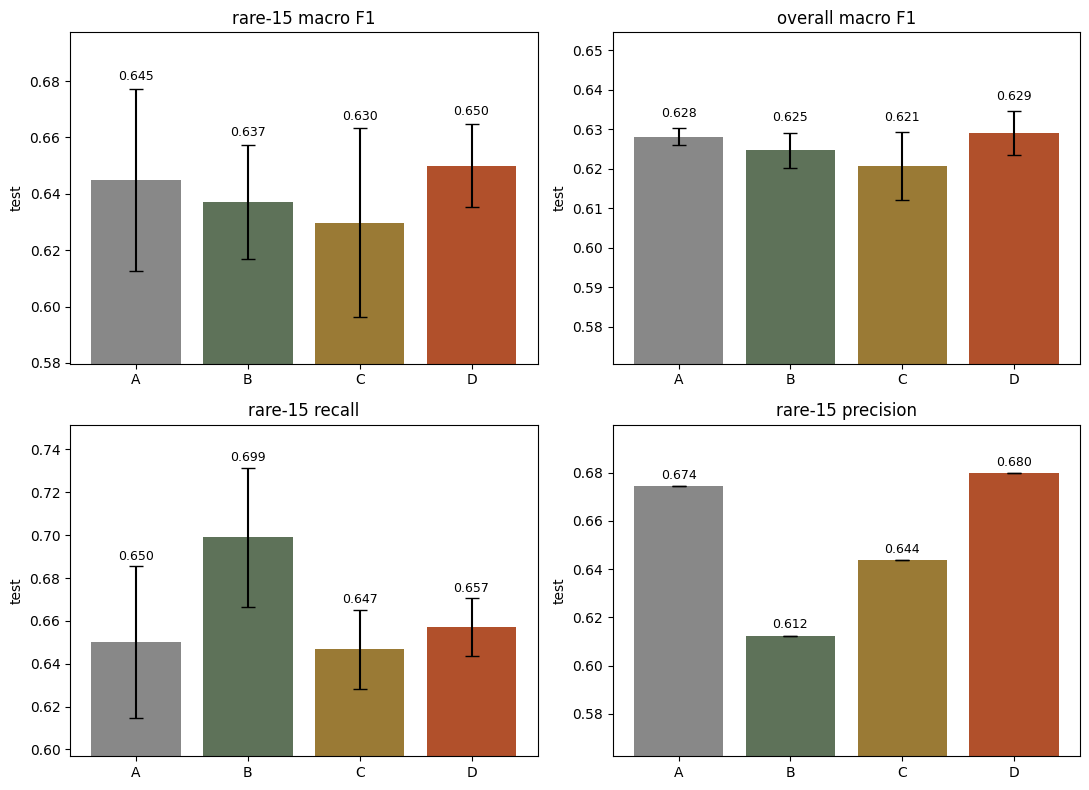

In [63]:
import matplotlib.pyplot as plt

(run_dir/'figs').mkdir(exist_ok=True)
conds = config['conditions']
x = range(len(conds))
colors = ['#888', '#5e7259', '#9a7a35', '#b1502b']

panels = [('rare', 'rare-15 macro F1'), ('overall', 'overall macro F1'),
          ('rec', 'rare-15 recall'), ('prec', 'rare-15 precision')]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (col, title) in zip(axes.ravel(), panels):
    means = [agg.loc[c, f'{col}_mean'] for c in conds]
    stds = [agg.loc[c, f'{col}_std'] if f'{col}_std' in agg.columns else 0 for c in conds]
    ax.bar(x, means, yerr=stds, capsize=5, color=colors)
    ax.set_xticks(x); ax.set_xticklabels(conds)
    ax.set_title(title); ax.set_ylabel('test')
    hi = max(m + s for m, s in zip(means, stds)) + 0.02
    ax.set_ylim(min(means) - 0.05, hi)
    for i, m in enumerate(means):
        ax.text(i, m + (stds[i] or 0) + 0.003, f'{m:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(run_dir/'figs'/'f1_by_condition.png', dpi=120)
plt.show()

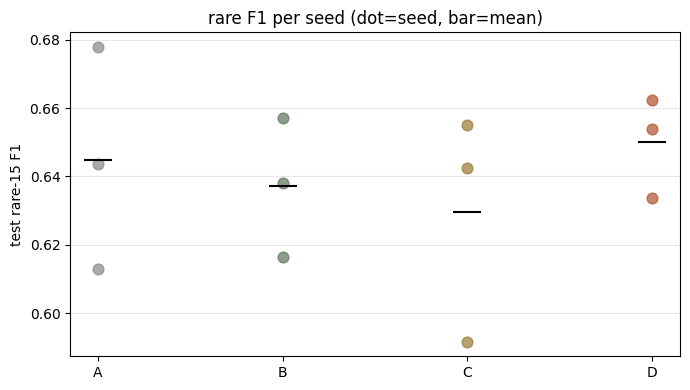

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
for i, c in enumerate(conds):
    sub_c = res[res.cond == c]
    ax.scatter([i]*len(sub_c), sub_c.test_rare_f1, s=60, alpha=0.7,
               color=['#888', '#5e7259', '#9a7a35', '#b1502b'][i])
    ax.scatter(i, agg.loc[c, 'rare_mean'], marker='_', s=400, color='k')  # mean
ax.set_xticks(x); ax.set_xticklabels(conds)
ax.set_ylabel('test rare-15 F1')
ax.set_title('rare F1 per seed (dot=seed, bar=mean)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(run_dir/'figs'/'rare_f1_per_seed.png', dpi=120)
plt.show()

### Per-species

ดู rare แต่ละตัวว่า D ดีขึ้นหรือแย่ลงกว่า A 

เทียบ F1 / recall / precision เรียงตาม ΔRecall

In [65]:
def ps_table(key):
    d = {}
    for r in rows:
        for sid, val in r[key].items():
            d.setdefault((r['cond'], sid), []).append(val)
    return {k: float(np.mean(v)) for k, v in d.items()}

f1m = ps_table('rare_f1_per_species')
rcm = ps_table('rare_recall_per_species')
pcm = ps_table('rare_precision_per_species')      # เพิ่ม precision

tbl = pd.DataFrame({'species_id': rare_ids,
                    'A_f1':  [f1m[('A', s)] for s in rare_ids], 'D_f1':  [f1m[('D', s)] for s in rare_ids],
                    'A_rec': [rcm[('A', s)] for s in rare_ids], 'D_rec': [rcm[('D', s)] for s in rare_ids],
                    'A_prec':[pcm[('A', s)] for s in rare_ids], 'D_prec':[pcm[('D', s)] for s in rare_ids]})
tbl = tbl.merge(lora_eval[['species_id', 'name', 'consistency', 'flag']], on='species_id')
tbl['dF1']   = (tbl.D_f1 - tbl.A_f1).round(3)
tbl['dRec']  = (tbl.D_rec - tbl.A_rec).round(3)
tbl['dPrec'] = (tbl.D_prec - tbl.A_prec).round(3)
tbl = tbl.sort_values('dRec')
print(tbl[['name', 'dF1', 'dRec', 'dPrec', 'D_rec', 'D_prec', 'consistency', 'flag']]
      .round(3).to_string(index=False))

                        name    dF1   dRec  dPrec  D_rec  D_prec  consistency            flag
              Alocasia odora -0.137 -0.125 -0.148  0.875   0.778        0.718              ok
            Kigelia africana -0.003 -0.111  0.286  0.370   0.850        0.492 low_consistency
       Nepenthes vieillardii -0.091 -0.067 -0.111  0.800   0.822        0.525              ok
    Gomphocarpus physocarpus -0.035 -0.048 -0.028  0.905   0.718        0.600              ok
        Tradescantia zebrina  0.030 -0.033  0.106  0.167   0.283        0.747              ok
             Cobaea scandens  0.000  0.000  0.000  0.800   0.761        0.615              ok
        Pereskia grandifolia  0.031  0.000  0.108  0.593   0.753        0.596              ok
          Petiveria alliacea -0.026  0.000 -0.072  0.400   0.450        0.527              ok
Dendrobium victoriae-reginae  0.000  0.000  0.000  0.900   0.845        0.689              ok
       Barringtonia asiatica -0.081  0.000 -0.143  0.800   0

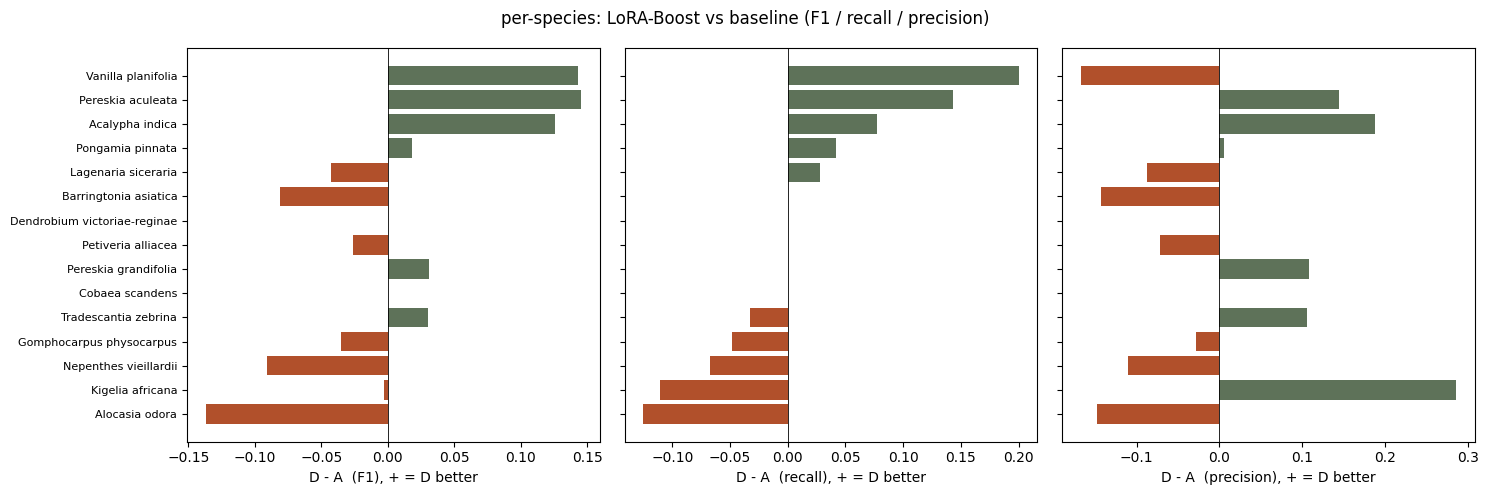

In [66]:
t = tbl.sort_values('dRec')
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, col, lab in [(axes[0], 'dF1', 'D - A  (F1)'),
                     (axes[1], 'dRec', 'D - A  (recall)'),
                     (axes[2], 'dPrec', 'D - A  (precision)')]:
    clr = ['#b1502b' if v < 0 else '#5e7259' for v in t[col]]
    ax.barh(range(len(t)), t[col], color=clr)
    ax.set_xlabel(f'{lab}, + = D better'); ax.axvline(0, color='k', lw=0.6)
axes[0].set_yticks(range(len(t))); axes[0].set_yticklabels(t['name'], fontsize=8)
fig.suptitle('per-species: LoRA-Boost vs baseline (F1 / recall / precision)')
plt.tight_layout(); plt.savefig(run_dir/'figs'/'per_species_DvsA.png', dpi=120); plt.show()

### Long-tail + effect

rare 15 ตัวบน long-tail ระบายตาม ΔRecall (เขียว=ดีขึ้น แดงแย่ลง) เทียบเส้น C (cut) / R (cap)

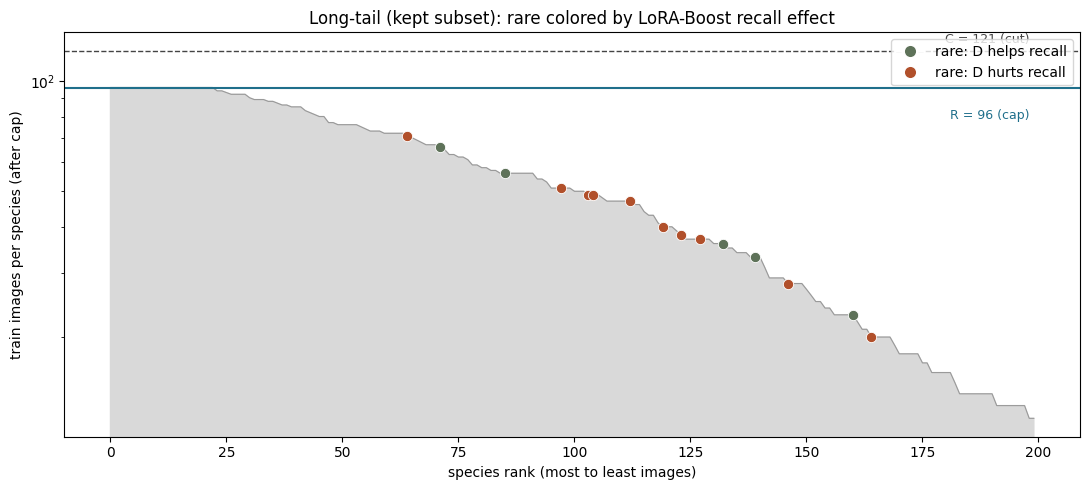

In [67]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

cnt = (sub[sub.split == 'train'].groupby('species_id').size()
       .sort_values(ascending=False).reset_index())
cnt.columns = ['species_id', 'n']
cnt['rank'] = range(len(cnt))
da = dict(zip(tbl.species_id, tbl['dRec']))     # ระบายสีตาม delta recall (primary)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(cnt['rank'], cnt['n'], color='0.85')
ax.plot(cnt['rank'], cnt['n'], color='0.6', lw=0.8)

for _, r in cnt[cnt.species_id.isin(rare_ids)].iterrows():
    color = '#5e7259' if da.get(r.species_id, 0) > 0 else '#b1502b'
    ax.scatter(r['rank'], r['n'], color=color, s=55, zorder=5,
               edgecolor='white', linewidth=0.6)

ax.axhline(C, color='#444', ls='--', lw=1)
ax.axhline(R, color='#1f6f8b', ls='-', lw=1.5)
ax.text(len(cnt) * 0.99, C * 1.05, f'C = {C:.0f} (cut)', ha='right', fontsize=9, color='#444')
ax.text(len(cnt) * 0.99, R * 0.82, f'R = {R:.0f} (cap)', ha='right', fontsize=9, color='#1f6f8b')

ax.set_yscale('log')
ax.set_xlabel('species rank (most to least images)')
ax.set_ylabel('train images per species (after cap)')
ax.set_title('Long-tail (kept subset): rare colored by LoRA-Boost recall effect')
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5e7259', markersize=9, label='rare: D helps recall'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#b1502b', markersize=9, label='rare: D hurts recall')],
    loc='upper right')

plt.tight_layout()
plt.savefig(run_dir/'figs'/'longtail_rare_effect.png', dpi=120)
plt.show()